In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
# load data
data_path1 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-04-city-of-london-street.csv"
data_path2 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-05-city-of-london-street.csv"
data_path3 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-06-city-of-london-street.csv"
data_path4 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-07-city-of-london-street.csv"
data_path5 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-08-city-of-london-street.csv"
data_path6 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-09-city-of-london-street.csv"
data_path7 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-10-city-of-london-street.csv"
data_path8 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-11-city-of-london-street.csv"
data_path9 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2025-12-city-of-london-street.csv"
data_path10 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2026-01-city-of-london-street.csv"
data_path11 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2026-02-city-of-london-street.csv"
data_path12 = "C:\\Users\\20244416\\OneDrive - TU Eindhoven\\Desktop\\Multidisciplinary CBL\\2026-03-city-of-london-street.csv"
data1 = pd.read_csv(data_path1)
data2 = pd.read_csv(data_path2)
data3 = pd.read_csv(data_path3)
data4 = pd.read_csv(data_path4)
data5 = pd.read_csv(data_path5)
data6 = pd.read_csv(data_path6)
data7 = pd.read_csv(data_path7)
data8 = pd.read_csv(data_path8)
data9 = pd.read_csv(data_path9)
data10 = pd.read_csv(data_path10)
data11 = pd.read_csv(data_path11)
data12 = pd.read_csv(data_path12)

In [3]:
allData = [data1, data2, data3, data4, data5, data6, data7, data8, data9, data10, data11, data12]

data = pd.concat(allData, ignore_index=True)

In [4]:
# checking that we can drop one of these columns and that they represent the same thing idk 

LSOA_names = pd.unique(data['LSOA name']).tolist()
LSOA_codes = pd.unique(data['LSOA code']).tolist()

print(len(LSOA_names))
print(len(LSOA_codes))

176
176


In [5]:
data = data.drop(columns=['Context', 'LSOA code'])

In [6]:
# checking what crime types there are
crimeTypes = pd.unique(data['Crime type']).tolist()
crimeTypes

['Other theft',
 'Robbery',
 'Theft from the person',
 'Anti-social behaviour',
 'Burglary',
 'Public order',
 'Shoplifting',
 'Bicycle theft',
 'Criminal damage and arson',
 'Other crime',
 'Violence and sexual offences',
 'Drugs',
 'Vehicle crime',
 'Possession of weapons']

In [7]:
# since the point of this is investigating the crime types per LSOA, the crimes that are missing either or both of these parameters will be dropped
data = data.dropna(subset=["LSOA name", "Crime type"])
data

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA name,Crime type,Last outcome category
0,b7dc0ac996bc0c0570819482bc06dc7a17d4150ab1de42...,2025-04,City of London Police,City of London Police,-0.107682,51.517786,On or near B521,Camden 027C,Other theft,Unable to prosecute suspect
1,c9877d69c1f144e288540abee5f9387fe293a709988b4c...,2025-04,City of London Police,City of London Police,-0.107682,51.517786,On or near B521,Camden 027C,Robbery,Status update unavailable
2,d77a5d5b2510b92e9ecc9a8b84f99ed1918a51581e5c4b...,2025-04,City of London Police,City of London Police,-0.107682,51.517786,On or near B521,Camden 027C,Theft from the person,Status update unavailable
3,d8402bf5cb5b34799377efaf705f84eed16b66bb34b599...,2025-04,City of London Police,City of London Police,-0.107682,51.517786,On or near B521,Camden 027C,Theft from the person,Investigation complete; no suspect identified
4,b23c1207c98960afd9e0d7f2d6d1e71aa907a4245a436d...,2025-04,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,Camden 028B,Other theft,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...,...,...,...
8851,6980bbf0f1dce812485bb1a1b3cc9d2c0fe6cfdd679546...,2026-03,City of London Police,City of London Police,-0.172805,51.524898,On or near Frampton Street,Westminster 009K,Other theft,Under investigation
8852,f9fdbb5288293cca86f6037d8b1c8dc2f7233a718144b3...,2026-03,City of London Police,City of London Police,-0.128701,51.511703,On or near Little Newport Street,Westminster 018A,Other theft,Under investigation
8853,600f72de8501df362dbd6aa50e54c3d5d297c023a78807...,2026-03,City of London Police,City of London Police,-0.111567,51.513757,On or near Middle Temple Lane,Westminster 018B,Other theft,Under investigation
8854,93fa31581454fcbf290f81df802ba24d4449f9bc01bbce...,2026-03,City of London Police,City of London Police,-0.111567,51.513757,On or near Middle Temple Lane,Westminster 018B,Theft from the person,Under investigation


In [8]:
LSOAs = pd.unique(data['LSOA name']).tolist()
LSOAs

['Camden 027C',
 'Camden 028B',
 'City of London 001A',
 'City of London 001B',
 'City of London 001C',
 'City of London 001E',
 'City of London 001F',
 'City of London 001G',
 'Enfield 013D',
 'Enfield 024A',
 'Enfield 031F',
 'Hackney 010A',
 'Hackney 033B',
 'Hackney 033C',
 'Islington 022D',
 'Islington 022G',
 'Islington 022H',
 'Newham 034A',
 'Pembrokeshire 015A',
 'Powys 006C',
 'Scarborough 004F',
 'Southwark 002B',
 'Southwark 006F',
 'Tower Hamlets 010G',
 'Tower Hamlets 015B',
 'Tower Hamlets 021F',
 'Tower Hamlets 027B',
 'Waltham Forest 018E',
 'Westminster 018B',
 'Barking and Dagenham 002C',
 'Barking and Dagenham 013A',
 'Barking and Dagenham 015E',
 'Bolton 015E',
 'Camden 017D',
 'Camden 026E',
 'Camden 027D',
 'East Staffordshire 011A',
 'Islington 005A',
 'Islington 023C',
 'Kirklees 048C',
 'Newham 033C',
 'Redbridge 033C',
 'Shropshire 015C',
 'Southwark 002C',
 'Southwark 035B',
 'Staffordshire Moorlands 001D',
 'Staffordshire Moorlands 005D',
 'Swansea 025F',
 

In [9]:
# a function that returns the types and counts for all crime types
def getCrimeLSOA(data, LSOA: str, crimeColumn: str):
    filteredData = data[data['LSOA name'] == LSOA]
    crimeCount = filteredData[crimeColumn].value_counts()
    
    return crimeCount

getCrimeLSOA(data, 'City of London 001A', 'Crime type')

Crime type
Other theft                     34
Theft from the person           28
Bicycle theft                   19
Violence and sexual offences    11
Vehicle crime                   10
Drugs                            9
Shoplifting                      7
Criminal damage and arson        7
Public order                     7
Anti-social behaviour            5
Burglary                         5
Robbery                          3
Other crime                      1
Name: count, dtype: int64

In [10]:
for LSOA in LSOAs:
    crimes = getCrimeLSOA(data, LSOA, 'Crime type')
    print(f'{LSOA}: {crimes}'
         )

Camden 027C: Crime type
Other theft                     6
Theft from the person           6
Drugs                           3
Burglary                        2
Robbery                         1
Criminal damage and arson       1
Violence and sexual offences    1
Bicycle theft                   1
Anti-social behaviour           1
Name: count, dtype: int64
Camden 028B: Crime type
Other theft                     8
Criminal damage and arson       4
Theft from the person           3
Violence and sexual offences    3
Shoplifting                     3
Burglary                        1
Public order                    1
Drugs                           1
Name: count, dtype: int64
City of London 001A: Crime type
Other theft                     34
Theft from the person           28
Bicycle theft                   19
Violence and sexual offences    11
Vehicle crime                   10
Drugs                            9
Shoplifting                      7
Criminal damage and arson        7
Public ord

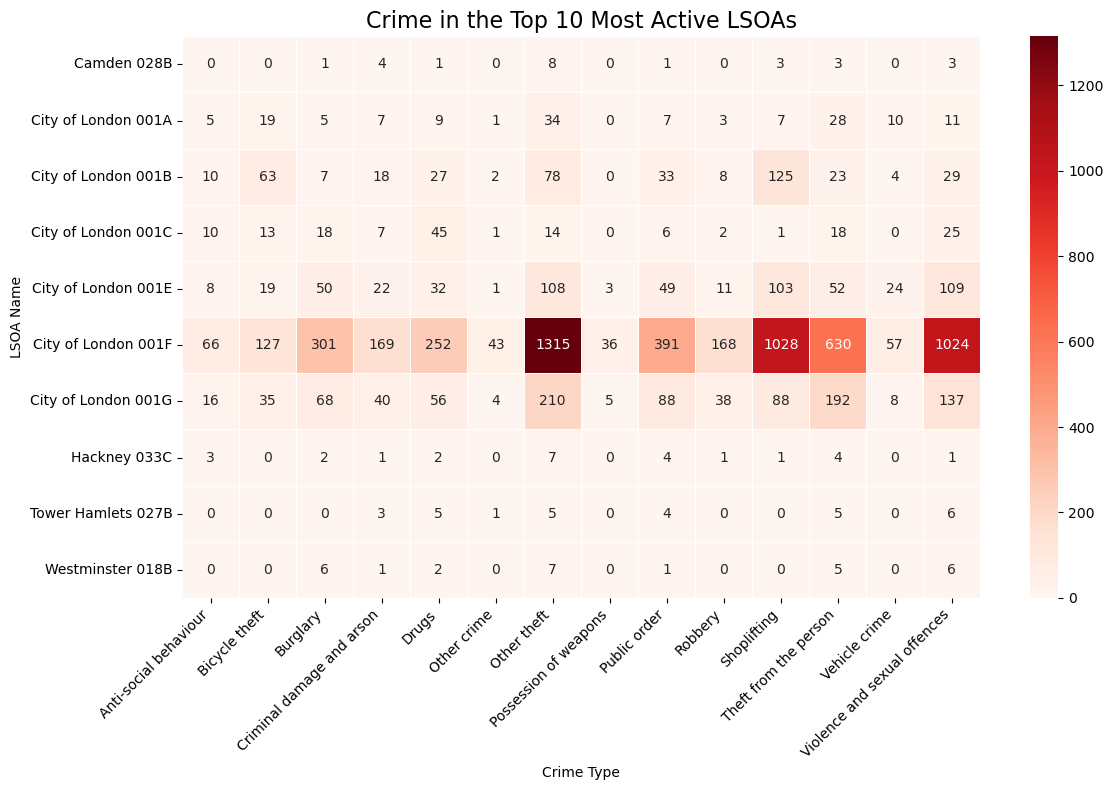

In [11]:
import seaborn as sns

# find the names of the top 10 most active LSOAs by total crime
top_lsoa_names = data['LSOA name'].value_counts().head(10).index

# filter the original dataframe to only include top 10 areas
top_lsoa_data = data[data['LSOA name'].isin(top_lsoa_names)]

crime_matrix = top_lsoa_data.groupby(['LSOA name', 'Crime type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(crime_matrix, cmap='Reds', annot=True, fmt='g', linewidths=0.5)

plt.title('Crime in the Top 10 Most Active LSOAs', fontsize=16)
plt.xlabel('Crime Type')
plt.ylabel('LSOA Name')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

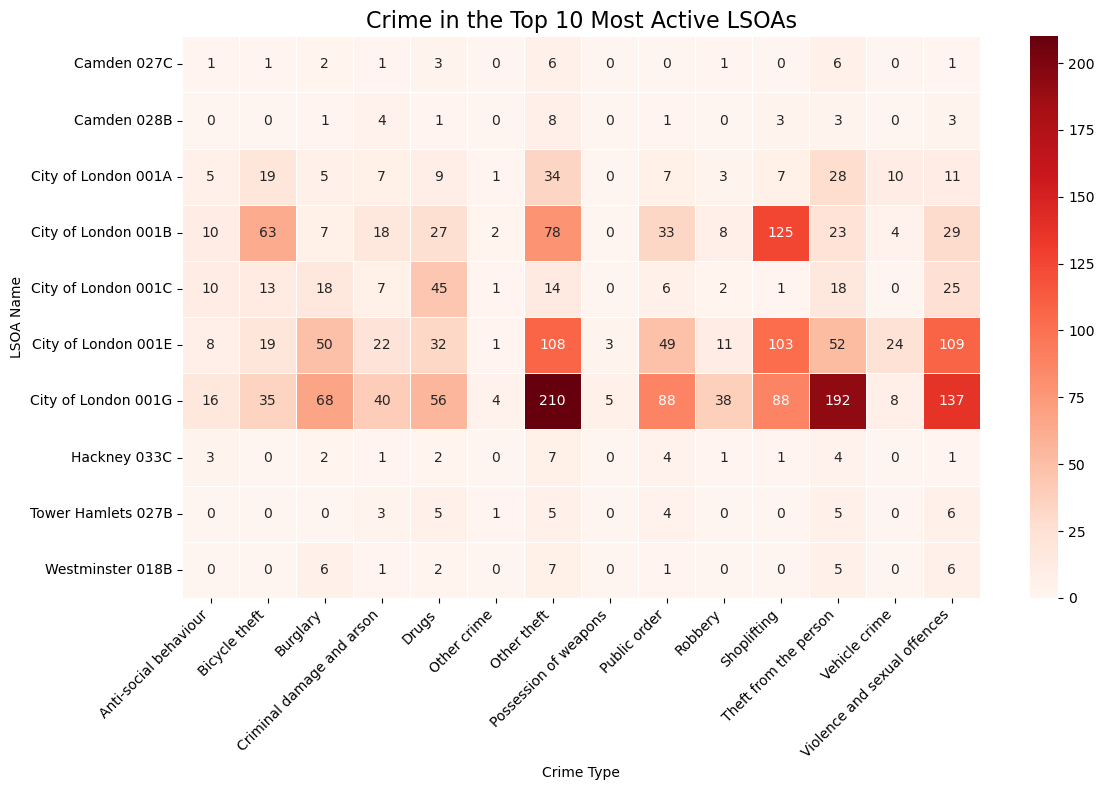

In [12]:
# do the same but exclude the outlier
clean_data = data[data['LSOA name'] != 'City of London 001F']

top_10_names = clean_data['LSOA name'].value_counts().head(10).index

top_lsoa_data = clean_data[clean_data['LSOA name'].isin(top_10_names)]
crime_matrix = top_lsoa_data.groupby(['LSOA name', 'Crime type']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(crime_matrix, cmap='Reds', annot=True, fmt='g', linewidths=0.5)

plt.title('Crime in the Top 10 Most Active LSOAs', fontsize=16)
plt.xlabel('Crime Type')
plt.ylabel('LSOA Name')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [13]:
# look closer at "easy to fix" crimes
target_crimes = ['Bicycle theft', 'Shoplifting'] 

# filter the clean data for these crimes
focused_data = data[data['Crime type'].isin(target_crimes)]

# create a quick summary table showing how these crimes usually end
outcome_summary = focused_data.groupby(['Crime type', 'Last outcome category']).size().unstack(fill_value=0)

outcome_summary

Last outcome category,Action to be taken by another organisation,Awaiting court outcome,Court result unavailable,Formal action is not in the public interest,Further action is not in the public interest,Further investigation is not in the public interest,Investigation complete; no suspect identified,Local resolution,Offender given a caution,Status update unavailable,Unable to prosecute suspect,Under investigation
Crime type,,,,,,,,,,,,
Bicycle theft,0,14,2,0,0,0,200,0,0,25,15,27
Shoplifting,1,166,95,1,5,9,531,46,1,124,237,149
